<a href="https://colab.research.google.com/github/Akhilaprabhu705/Robotics/blob/main/Task1_Smart_Farming_Field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SMART FARMING FIELD**

This line installs the pybullet simulation library into google colab environment

In [1]:
!pip install pybullet

In [2]:
import pybullet as p
import pybullet_data
import os
import matplotlib.pyplot as plt
import numpy as np

The code below creates a folder "farm_objects" to store all urdf files

In [3]:
os.makedirs("farm_objects", exist_ok=True)

*"Healthy crop"* - Below code creates a urdf model for healthy crops  with **Color : Green**  and **Shape: Cylinder**. This shows the crops in the farm

In [4]:
healthy_crop = '''
<?xml version="1.0"?>
<robot name="healthy_crop">

  <link name="baseLink">

    <visual>
      <geometry>
        <cylinder radius="0.25" length="0.8"/>
      </geometry>

      <origin xyz="0 0 0.4"/>

      <material name="green">
        <color rgba="0 1 0 1"/>
      </material>
    </visual>

    <collision>
      <geometry>
        <cylinder radius="0.25" length="0.8"/>
      </geometry>

      <origin xyz="0 0 0.4"/>
    </collision>

  </link>
</robot>
'''

"Dry crops" -Below code creates a urdf model for dry or unhealthy crop. **Color:Brown **and** bold text SHape: Cylinder**

In [5]:
dry_crop = '''
<?xml version="1.0"?>
<robot name="dry_crop">

  <link name="baseLink">

    <visual>
      <geometry>
        <cylinder radius="0.25" length="0.8"/>
      </geometry>

      <origin xyz="0 0 0.4"/>

      <material name="brown">
        <color rgba="0.6 0.3 0 1"/>
      </material>
    </visual>

    <collision>
      <geometry>
        <cylinder radius="0.25" length="0.8"/>
      </geometry>

      <origin xyz="0 0 0.4"/>
    </collision>

  </link>
</robot>
'''

"Water Tank"- Water Tank urdf model. It represents a water tank in the farm. Color:Blue and Shape: Cuboid(BOX). I have made it slightly taller so that its clearly visible amongst the crops.

In [6]:
water_tank = '''
<?xml version="1.0"?>
<robot name="water_tank">

  <link name="baseLink">

    <visual>
      <geometry>
        <box size="1.2 1.2 2.0"/>
      </geometry>

      <origin xyz="0 0 1.0"/>

      <material name="blue">
        <color rgba="0 0 1 1"/>
      </material>
    </visual>

    <collision>
      <geometry>
        <box size="1.2 1.2 2.0"/>
      </geometry>

      <origin xyz="0 0 1.0"/>
    </collision>

  </link>
</robot>
'''

### "Fence"- Fence urdf is box representing as a fence/ boundary  wall, **Color: Gray**. They are 4 in number so that it forms and enclosure around the farm field.

In [7]:
fence = '''
<?xml version="1.0"?>
<robot name="fence">

  <link name="baseLink">

    <visual>
      <geometry>
        <box size="10 0.2 1.2"/>
      </geometry>

      <origin xyz="0 0 0.35"/>

      <material name="gray">
        <color rgba="0.5 0.5 0.5 1"/>
      </material>
    </visual>

    <collision>
      <geometry>
        <box size="3 0.2 0.7"/>
      </geometry>

      <origin xyz="0 0 0.35"/>
    </collision>

  </link>
</robot>
'''

"Sensor Pole"- Sensor pole urdf represents a sensor/landmark pole. It has 2 elements - pole body and a sphere so that its clearly visible to us. **Yellow cylinder with orange sphere**

In [8]:
sensor_pole = '''
<?xml version="1.0"?>
<robot name="sensor_pole">

  <link name="baseLink">

    <!-- Vertical Pole -->
    <visual>
      <origin xyz="0 0 1"/>

      <geometry>
        <cylinder radius="0.18" length="2"/>
      </geometry>

      <material name="bright_yellow">
        <color rgba="1 1 0 1"/>
      </material>
    </visual>

    <collision>
      <origin xyz="0 0 1"/>

      <geometry>
        <cylinder radius="0.18" length="2"/>
      </geometry>
    </collision>

    <!-- Top Sphere -->
    <visual>
      <origin xyz="0 0 2.1"/>

      <geometry>
        <sphere radius="0.3"/>
      </geometry>

      <material name="orange">
        <color rgba="1 0.5 0 1"/>
      </material>
    </visual>

  </link>
</robot>
'''

In the below code all 5 Urdf strings are written into .urdf files present inside the farm_objects folder so the PyBullet can load them

In [9]:
with open("farm_objects/healthy_crop.urdf", "w") as f:
    f.write(healthy_crop)

with open("farm_objects/dry_crop.urdf", "w") as f:
    f.write(dry_crop)

with open("farm_objects/water_tank.urdf", "w") as f:
    f.write(water_tank)

with open("farm_objects/fence.urdf", "w") as f:
    f.write(fence)

with open("farm_objects/sensor_pole.urdf", "w") as f:
    f.write(sensor_pole)

In [10]:
physicsClient = p.connect(p.DIRECT) #p.Direct starts the pybullet in direct mode(without the gui window). Gravity is set to -9.8

p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0,0,-9.8)

planeId = p.loadURDF("plane.urdf")

In [11]:
object_semantics = {} #here an empty dictionary is created  that will store each objects ID , name and the role.

The 4 healthhy crops are placed at particular positions so that they form a row. Each of these are added to *object_semantics* with role *normal_zone*

In [12]:
crop_positions = [(-3, -1, 0), (-1, -1, 0), (1, -1, 0), (3, -1, 0)]
for i, pos in enumerate(crop_positions):
    cid = p.loadURDF("farm_objects/healthy_crop.urdf", pos)
    object_semantics[cid] = {"name": f"Healthy Crop {i+1}", "role": "normal_zone"}

Two Dry plants(Brown cylinder) are placed near the healthy plants. Each of them are added to *object_semantics* with the role *normal_zone*

In [13]:
dry_positions = [(-2, 1, 0), (2, 1, 0)]
for i, pos in enumerate(dry_positions):
    did = p.loadURDF("farm_objects/dry_crop.urdf", pos)
    object_semantics[did] = {"name": f"Dry Plant {i+1}", "role": "inspection_target"}

In [14]:
# Water tank is placed at the back of the field and its added to semantic with role resource
tank = p.loadURDF("farm_objects/water_tank.urdf", [0, 3.5, 0])
object_semantics[tank] = {"name": "Water Tank", "role": "resource"}

4 fences are placed to create a boundary, all of these are added with role *obstacle*

In [15]:
fence1 = p.loadURDF("farm_objects/fence.urdf", [0, -5, 0])
object_semantics[fence1] = {"name": "Fence South", "role": "obstacle"}

fence2 = p.loadURDF("farm_objects/fence.urdf", [0, 5, 0])
object_semantics[fence2] = {"name": "Fence North", "role": "obstacle"}

fence3 = p.loadURDF("farm_objects/fence.urdf", [-5, 0, 0],
                    p.getQuaternionFromEuler([0, 0, 1.5708]))
object_semantics[fence3] = {"name": "Fence West", "role": "obstacle"}

fence4 = p.loadURDF("farm_objects/fence.urdf", [5, 0, 0],
                    p.getQuaternionFromEuler([0, 0, 1.5708]))
object_semantics[fence4] = {"name": "Fence East", "role": "obstacle"}

In [16]:
# Sensor poles are added inside corners of the field and added with role
pole1 = p.loadURDF("farm_objects/sensor_pole.urdf", [-3.5, 3, 0])
object_semantics[pole1] = {"name": "Sensor Pole 1", "role": "landmark"}

pole2 = p.loadURDF("farm_objects/sensor_pole.urdf", [3.5, 3, 0])
object_semantics[pole2] = {"name": "Sensor Pole 2", "role": "landmark"}

in range(200), the simuation is run for 200 steps s that all the objects settle in their final positions before the image is captured

In [17]:
for _ in range(200):
  p.stepSimulation()

In [18]:
print("Number of objects:", len(object_semantics))

for obj_id, info in object_semantics.items():
    print(obj_id, info)

Number of objects: 13
1 {'name': 'Healthy Crop 1', 'role': 'normal_zone'}
2 {'name': 'Healthy Crop 2', 'role': 'normal_zone'}
3 {'name': 'Healthy Crop 3', 'role': 'normal_zone'}
4 {'name': 'Healthy Crop 4', 'role': 'normal_zone'}
5 {'name': 'Dry Plant 1', 'role': 'inspection_target'}
6 {'name': 'Dry Plant 2', 'role': 'inspection_target'}
7 {'name': 'Water Tank', 'role': 'resource'}
8 {'name': 'Fence South', 'role': 'obstacle'}
9 {'name': 'Fence North', 'role': 'obstacle'}
10 {'name': 'Fence West', 'role': 'obstacle'}
11 {'name': 'Fence East', 'role': 'obstacle'}
12 {'name': 'Sensor Pole 1', 'role': 'landmark'}
13 {'name': 'Sensor Pole 2', 'role': 'landmark'}


"Projection Matrix" - is used to set up the camera lens

In [19]:
projectionMatrix = p.computeProjectionMatrixFOV(
    fov=60,
    aspect=1.0,
    nearVal=0.1,
    farVal=100
)

In [20]:
# Camera1 (TOP View) camera is placed directly above at the height 18, it gives a bird eye view of the entire field layout
viewMatrix1 = p.computeViewMatrix(
    cameraEyePosition=[0, 0, 18],
    cameraTargetPosition=[0, 0, 0],
    cameraUpVector=[0, 1, 0]
)

In [21]:
#Camera 2 gives side view. Camera is placed diagonally at thec center. It gives a horizontal perspective
viewMatrix2 = p.computeViewMatrix(
    cameraEyePosition=[12, 0, 6],
    cameraTargetPosition=[0, 0, 0],
    cameraUpVector=[0, 0, 1]
)

In [22]:
#camera 3 - angled view this gives a 3d perspective showing the layout and the depth.
viewMatrix3 = p.computeViewMatrix(
    cameraEyePosition=[10, -10, 8],
    cameraTargetPosition=[0, 0, 0],
    cameraUpVector=[0, 0, 1]
)

Capture_image - its a function that takes a matrix and returns a RGB image array using p.getCameraImage().

In [23]:
def capture_image(viewMatrix):

    width, height, rgbImg, depthImg, segImg = p.getCameraImage(
        width=900,
        height=900,
        viewMatrix=viewMatrix,
        projectionMatrix=projectionMatrix,
        renderer=p.ER_BULLET_HARDWARE_OPENGL
    )

    rgb_array = np.array(rgbImg)

    rgb_array = rgb_array[:, :, :3]

    return rgb_array

In [24]:
# all 3 images calls the capture function 3 times using eaach of the view matrix to get all tye 3 camera images
img1 = capture_image(viewMatrix1)
img2 = capture_image(viewMatrix2)
img3 = capture_image(viewMatrix3)

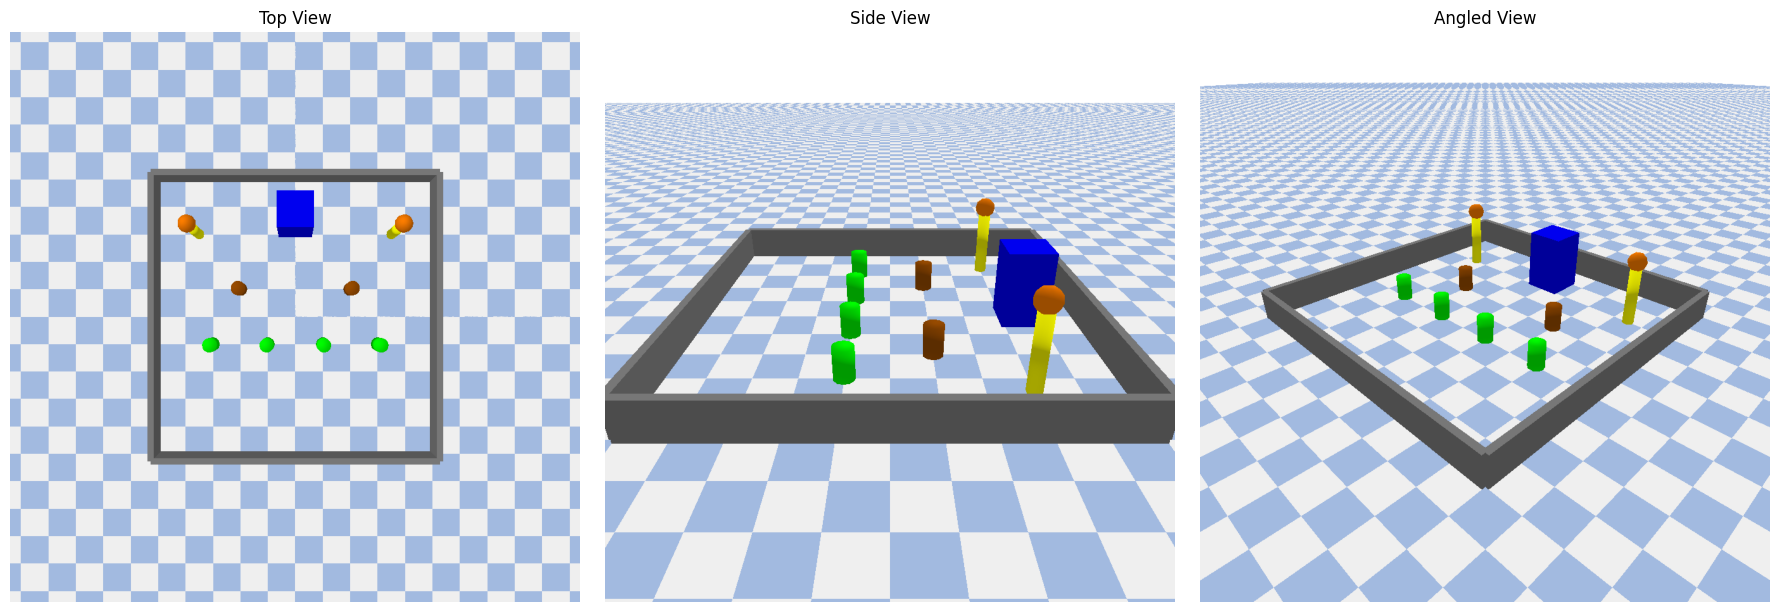

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img1)
axes[0].set_title("Top View")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title("Side View")
axes[1].axis("off")

axes[2].imshow(img3)
axes[2].set_title("Angled View")
axes[2].axis("off")

plt.tight_layout()
plt.show()

The nearest object query simulates the rbot to position 0,0,0 and it finds the nearest inspection_target, which is the dry plant. Here numpy distance calculations are used. The nearest dry plant is dry plant 2 with the distance 2.236

In [26]:
robot_position = np.array([0, 0, 0])

nearest_object = None
minimum_distance = float("inf")

for obj_id, info in object_semantics.items():

    # Only check dry plants
    if info["role"] == "inspection_target":
      position, orientation = p.getBasePositionAndOrientation(obj_id)
      distance = np.linalg.norm(robot_position - np.array(position))
      if distance < minimum_distance:
            minimum_distance = distance
            nearest_object = info["name"]

print("Nearest Dry Plant:", nearest_object)
print("Distance:", minimum_distance)

Nearest Dry Plant: Dry Plant 2
Distance: 2.2360681799959377


In [27]:
for obj_id, info in object_semantics.items():
  position, _ = p.getBasePositionAndOrientation(obj_id)
  print(f"Object: {info['name']} | "f"Role: {info['role']} | "f"Position: {position}")

Object: Healthy Crop 1 | Role: normal_zone | Position: (-2.999999995775826, -1.0000000244496692, 0.0009905138447493366)
Object: Healthy Crop 2 | Role: normal_zone | Position: (-0.9999999974829828, -1.0000000130275495, 0.0009902482720841744)
Object: Healthy Crop 3 | Role: normal_zone | Position: (0.9999999918308653, -0.9999999976183865, 0.0009903574623788278)
Object: Healthy Crop 4 | Role: normal_zone | Position: (2.9999999850138868, -0.9999999973837521, 0.0009904614260553642)
Object: Dry Plant 1 | Role: inspection_target | Position: (-2.0000000022476323, 0.9999999758856581, 0.000990462680290793)
Object: Dry Plant 2 | Role: inspection_target | Position: (1.9999999794502805, 1.000000003458747, 0.0009903896848471327)
Object: Water Tank | Role: resource | Position: (-8.741188542691772e-12, 3.4999999999978786, -9.91053398197588e-06)
Object: Fence South | Role: obstacle | Position: (-4.944774011797356e-13, -5.000000000007973, -1.0412274442181118e-05)
Object: Fence North | Role: obstacle | Po

Disconnecting the pybullet is very important to prevent the objects from getting spawned multiple times.

In [28]:
p.disconnect()